# Firasa Sanity Check: Naive Benchmarks & Logistic Regression

Objective: before jumping into XGBoost and LightGBM, we need two things to compare against: naive baselines that show what doing nothing smart looks like, and a Logistic Regression sanity check that confirms the aggregated customer-level data actually carries real predictive signal.

**Data:** `amex_agg_train.parquet`, the aggregated train set produced at the end of the EDA notebook (mean, std, min, max, last per feature, one row per customer). This includes the EDA finalization's engineered columns: missing-indicator flags (`{col}_was_missing`, 92 columns), a per-customer `n_statements` feature, and `log1p` versions of heavily-skewed columns (111 columns), all aggregated the same way as every other feature, bringing the table to **1,804 columns**.


## Step 1: Upload the Aggregated Parquet Files from EDA


## Step 2: Naive Baseline Models

Before trusting any real model's score, I want to know what the floor looks like.
- **Majority Class:** always predict no default. This is the accuracy a lazy model would get just by exploiting the class imbalance, and it's why accuracy alone is a misleading metric here.
- **Single Feature Heuristic:** rank customers by `P_2_last` alone (the feature most correlated with `target` in the EDA). This tells me how much signal is already in just one feature, so we can judge later whether the full feature set (and a real model) is actually adding value.


In [ ]:
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

DATA_DIR = '/content/data'

df_clean = pd.read_parquet(f'{DATA_DIR}/amex_agg_train.parquet')

print(f"The dataset size: {df_clean.shape}")

y_true = df_clean['target']

y_pred_majority = [0] * len(y_true)
y_pred_proba_majority = [0.0] * len(y_true)

acc_majority = accuracy_score(y_true, y_pred_majority)
auc_majority = roc_auc_score(y_true, y_pred_proba_majority)

print("\nNaive Model 1: Majority Class (Always Predict 0)")
print(f"Accuracy: {acc_majority:.4f} (This is misleading!)")
print(f"ROC-AUC:  {auc_majority:.4f} (Baseline for random guessing)")


median_p2 = df_clean['P_2_last'].median()
p2_risk_scores = -df_clean['P_2_last'].fillna(median_p2)

auc_p2 = roc_auc_score(y_true, p2_risk_scores)

print("\nNaive Model 2: Single Feature Heuristic (Using only P_2)")
print(f"ROC-AUC:  {auc_p2:.4f}")


The dataset size: (33185, 1804)

Naive Model 1: Majority Class (Always Predict 0)
Accuracy: 0.7471 (This is misleading!)
ROC-AUC:  0.5000 (Baseline for random guessing)

Naive Model 2: Single Feature Heuristic (Using only P_2)
ROC-AUC:  0.9154


**Insight:** The majority-class baseline hit **74.71% accuracy** while doing nothing at all, exactly the trap the EDA notebook warned about with the ~75/25 class imbalance, and why accuracy alone won't be a metric we trust for this problem. Its ROC-AUC of 0.5000 is just the expected score for random/constant guessing.

The single-feature heuristic P_2 alone scored **0.9154 ROC-AUC**, a strong result for one column that confirms P_2 really is the standout predictor the EDA correlation analysis pointed to. That sets the bar any real model needs to clearly beat to prove the rest of the feature set is worth the added complexity.


## Step 3: Logistic Regression Sanity Check

Now the real test: a Logistic Regression using **all** the aggregated features (not just P_2), through a proper preprocessing pipeline (median imputation and scaling for numeric features, most-frequent imputation and one-hot for categorical ones), with `class_weight='balanced'` to account for the class imbalance. `customer_ID` is set as the index (not a feature), and the split is
`test_size=0.2, random_state=42, stratify=y`. We reuse this exact split later for XGBoost/LightGBM so the comparison is fair.

The `log1p` columns from the EDA were added specifically to help this Logistic Regression pipeline, since it's a linear model sensitive to skew, while the raw originals stay in the table too for reference. The pipeline below picks up numeric vs. categorical columns automatically, so no code change is needed to include them: they just flow in as extra numeric features through `numeric_transformer`.


In [ ]:
# Logistic Regression Sanity Check (Aggregated Data)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


df_tabular = pd.read_parquet(f'{DATA_DIR}/amex_agg_train.parquet')

if 'customer_ID' in df_tabular.columns:
    df_tabular = df_tabular.set_index('customer_ID')

print(f"Data shape: {df_tabular.shape}")

drop_cols = ['S_2', 'year', 'month', 'target']
X = df_tabular.drop(columns=drop_cols, errors='ignore')
y = df_tabular['target']

numeric_features = X.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])



logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)

clf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', logreg)])

clf_pipeline.fit(X_train, y_train)

y_pred = clf_pipeline.predict(X_test)
y_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]


Data shape: (33185, 1803)


## Step 4: Evaluate the Logistic Regression

Logistic Regression Sanity Check evalution metrics:

ROC-AUC Score : 0.9513

Classification Report:

                precision    recall  f1-score   support

No Default (0)       0.96      0.88      0.92      4959
   Default (1)       0.71      0.88      0.79      1678

      accuracy                           0.88      6637
     macro avg       0.83      0.88      0.85      6637
  weighted avg       0.89      0.88      0.88      6637



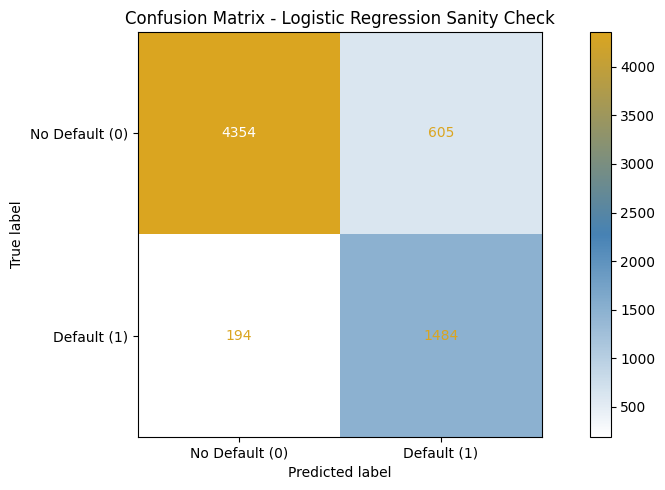

In [ ]:
print("Logistic Regression Sanity Check evaluation metrics:\n")

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score : {roc_auc:.4f}\n")


print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Default (0)', 'Default (1)']))


from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list('FirasaCmap', ['white', 'steelblue', '#DAA520'])

fig, ax = plt.subplots(figsize=(10, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)'])

disp.plot(cmap=custom_cmap, ax=ax, values_format='d')

plt.title('Confusion Matrix - Logistic Regression Sanity Check')
plt.tight_layout()
plt.show()

**Insight:** Using the full feature set (1,803 columns after `customer_ID` became the index), Logistic Regression scored **0.9513 ROC-AUC**, clearly ahead of the single-feature P_2 heuristic (0.9154), which tells me the rest of the aggregated features (not just P_2) are adding real, measurable signal, not just noise. This is also an improvement over the pre-finalization baseline (0.9482), consistent with the EDA finalization adding genuine signal (e.g. `n_statements`) rather than just extra columns.

| Class | Precision | Recall | F1 |
|---|---|---|---|
| No Default (0) | 0.96 | 0.88 | 0.92 |
| Default (1) | 0.71 | 0.88 | 0.79 |

`class_weight='balanced'` did its job: recall on the Default class is **0.88**, meaning the model catches 88% of customers who actually default, the priority for an early-warning system, where missing a real default is more costly than a false alarm (up slightly from 0.87 pre-finalization). The trade-off is precision (0.71), about 29% of predicted defaults are false positives, which is the expected cost of prioritizing recall this way.

**Bottom line:** the aggregated data is clearly informative, and **0.9513** is now our baseline number to beat with XGBoost/LightGBM, evaluated on this exact same train/validation split, for a fair comparison.